<a href="https://colab.research.google.com/github/tapasyapandiyan/Dwarka-Nexus/blob/main/dwarka_nexus_colab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Installing core dependencies for QAOA simulation and spatial analysis
!pip install qiskit qiskit-aer numpy pandas networkx matplotlib -q

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

print(" Qiskit and Spatial Graphing Libraries Loaded Successfully.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.5 MB/s eta 0:00:00
 Qiskit and Spatial Graphing Libraries Loaded Successfully.


In [2]:
# Ingesting GIS matrix generated in Phase 2
csv_path = 'dwarka_archeology_grid.csv'

try:
    df = pd.read_csv(csv_path)
    print("[+] Ingested Spatial Archaeological Grid:")
    print(df[['Node_ID', 'Site', 'Lat', 'Lon', 'Depth_m', 'Priority_Rank']])
except FileNotFoundError:
    print(f"[-] '{csv_path}' not found. Generating default grid array...")
    data = [
        {"Node_ID": "Node_0", "Site": "Submerged Bastion A", "Lat": 22.2464, "Lon": 68.9642, "Depth_m": 7.0, "Priority_Rank": 1},
        {"Node_ID": "Node_1", "Site": "Stone Anchor Zone B", "Lat": 22.2470, "Lon": 68.9650, "Depth_m": 8.5, "Priority_Rank": 2},
        {"Node_ID": "Node_2", "Site": "Foundation Wall C",   "Lat": 22.2458, "Lon": 68.9638, "Depth_m": 6.8, "Priority_Rank": 1},
        {"Node_ID": "Node_3", "Site": "Deep Anomaly D",     "Lat": 22.2481, "Lon": 68.9661, "Depth_m": 11.2, "Priority_Rank": 3}
    ]
    df = pd.DataFrame(data)

# Computing 3D Subsea Distance Cost Matrix (Combining 2D spatial distance + Depth penalty)
num_nodes = len(df)
cost_matrix = np.zeros((num_nodes, num_nodes))

for i in range(num_nodes):
    for j in range(num_nodes):
        if i != j:
            # Euclidean distance in lat/lon space
            spatial_dist = np.sqrt((df.loc[i, 'Lat'] - df.loc[j, 'Lat'])**2 +
                                   (df.loc[i, 'Lon'] - df.loc[j, 'Lon'])**2)

            # Vertical depth delta (bathymetric cost factor for AUV thrusters)
            depth_delta = abs(df.loc[i, 'Depth_m'] - df.loc[j, 'Depth_m']) * 0.002

            cost_matrix[i][j] = np.round(spatial_dist + depth_delta, 5)

print("\n[+] Formulated AUV Subsea Traversal Cost Matrix:")
print(cost_matrix)


[-] 'dwarka_archeology_grid.csv' not found. Generating default grid array...

[+] Formulated AUV Subsea Traversal Cost Matrix:
[[0.      0.004   0.00112 0.01095]
 [0.004   0.      0.0051  0.00696]
 [0.00112 0.0051  0.      0.01205]
 [0.01095 0.00696 0.01205 0.     ]]


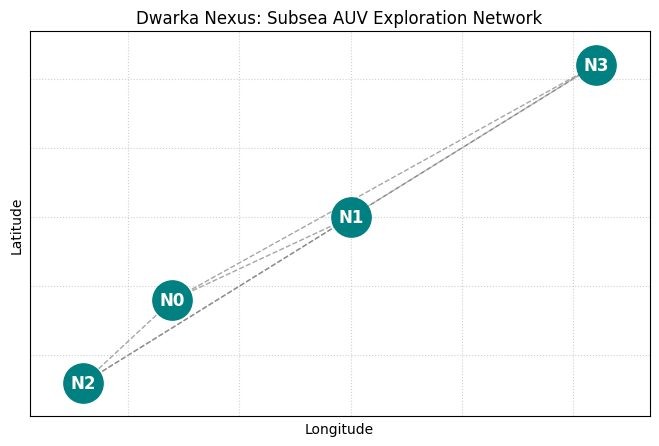

In [3]:
# Constructing NetworkX Graph for Quantum QAOA mapping
G = nx.Graph()

for i in range(num_nodes):
    G.add_node(i, pos=(df.loc[i, 'Lon'], df.loc[i, 'Lat']), name=df.loc[i, 'Site'])

for i in range(num_nodes):
    for j in range(i + 1, num_nodes):
        G.add_edge(i, j, weight=cost_matrix[i][j])

# Visualizing Node Network
pos = {i: (df.loc[i, 'Lon'], df.loc[i, 'Lat']) for i in range(num_nodes)}
plt.figure(figsize=(8, 5))
nx.draw_networkx_nodes(G, pos, node_color='#008080', node_size=800)
nx.draw_networkx_edges(G, pos, edge_color='gray', style='dashed', alpha=0.7)
nx.draw_networkx_labels(G, pos, labels={i: f"N{i}" for i in range(num_nodes)}, font_color='white', font_weight='bold')

plt.title("Dwarka Nexus: Subsea AUV Exploration Network")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


QAOA Execution Complete.

Top Evaluated Path States (Bitstrings):
State |0100> : 159 shots (7.76%)
State |0001> : 145 shots (7.08%)
State |1111> : 135 shots (6.59%)
State |1110> : 134 shots (6.54%)


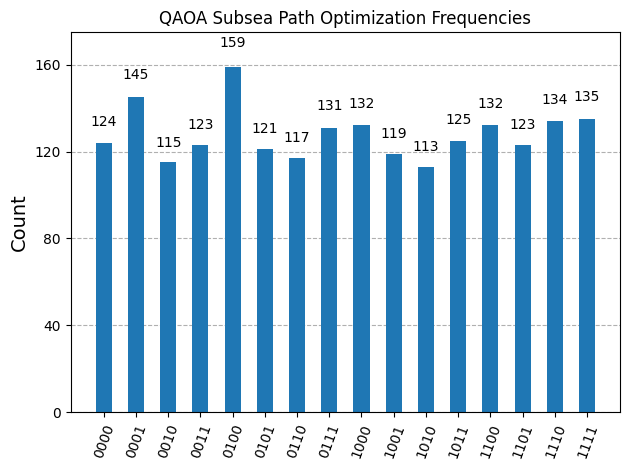

In [4]:
# Parameterized Quantum Approximate Optimization Algorithm (QAOA) Circuit
num_qubits = num_nodes
qaoa = QuantumCircuit(num_qubits)

# 1. Stateing Preparation: Equal Superposition via Hadamard Gates
qaoa.h(range(num_qubits))
qaoa.barrier()

# 2. Problem Hamiltonian (Cost Layer): Entangle nodes using RZZ gates proportional to distance weights
gamma = 0.45  # Variational cost parameter
for i, j in G.edges():
    weight = G[i][j]['weight']
    qaoa.rzz(2 * gamma * weight, i, j)

qaoa.barrier()

# 3. Mixer Hamiltonian: Transverse-field rotations via RX gates
beta = 0.30  # Variational mixer parameter
for i in range(num_qubits):
    qaoa.rx(2 * beta, i)

# 4. Measurement Phase
qaoa.measure_all()

# Execute Circuit on AerSimulator
backend = AerSimulator()
shots = 2048
job = backend.run(qaoa, shots=shots)
result = job.result()
counts = result.get_counts()

print("QAOA Execution Complete.")
print("\nTop Evaluated Path States (Bitstrings):")
sorted_states = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:4]
for bitstring, count in sorted_states:
    probability = (count / shots) * 100
    print(f"State |{bitstring}> : {count} shots ({probability:.2f}%)")

# Plot Measurement Frequencies
plot_histogram(counts, title="QAOA Subsea Path Optimization Frequencies")
